In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Load the Apple stock data
df = pd.read_csv("aapl_cleaned.csv")

In [ ]:
# Convert Date column to datetime format  and set date as index
df['Date'] = pd.to_datetime(df['Date'])

# Sort the dataset from oldest to newest
df = df.sort_values('Date')

# Set Date as the index
df.set_index('Date', inplace=True)

In [4]:
data = df[['Close']]

In [ ]:
# Use 70% of the earlier data for training

train_size = int(len(data) * 0.70)

#Creating training data
train = data.iloc[:train_size]

#Use the remaining for testing
test = data.iloc[train_size:]

In [ ]:
# Store the training closing prices in a list
history = train['Close'].tolist()

# Create an empty list to save predictions
predictions = []

# Predict the test closing prices one day at a time
for i in range(len(test)):

    # Create the baseline ARIMA model
    model = ARIMA(history, order=(3,1,0))

    # Train the ARIMA model
    model_fit = model.fit()

    # Predict the next closing price
    prediction = model_fit.forecast()[0]

    # Save the prediction
    predictions.append(prediction)
    # Add the actual closing price for the next prediction
    history.append(test['Close'].iloc[i])

In [ ]:
# Create a dataframe to compare actual and predicted prices
results = pd.DataFrame()

# Add the actual test prices
results['Actual'] = test['Close'].values

# Add the predicted prices
results['Predicted'] = predictions

# Use the test dates as the index
results.index = test.index
results.head()

,Actual,Predicted
Date,,
2022-01-19,162.512573,166.381171
2022-01-20,160.831070,162.717656
2022-01-21,158.778015,160.992000
2022-01-24,158.005722,158.990149
2022-01-25,156.206848,158.064351


In [8]:
mae = mean_absolute_error(results['Actual'], results['Predicted'])

In [9]:
rmse = np.sqrt(mean_squared_error(results['Actual'], results['Predicted']))

In [10]:
r2 = r2_score(results['Actual'], results['Predicted'])

In [11]:
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,4))

MAE : 2.13
RMSE : 2.84
R2 Score : 0.9907


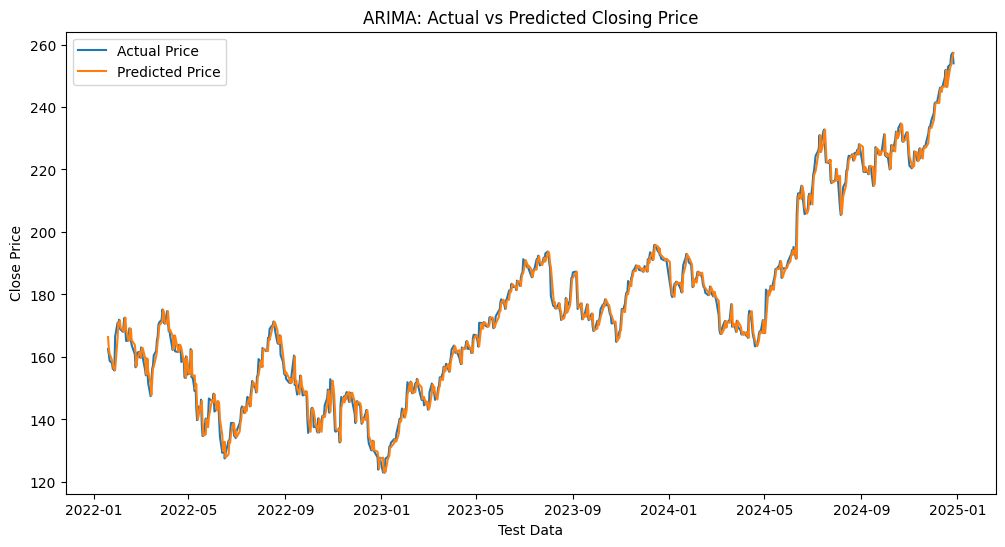

In [ ]:
# Compare the actual and predicted closing prices
plt.figure(figsize=(12,6))

plt.plot(test.index,results['Actual'],label='Actual Price')

plt.plot(test.index,results['Predicted'],label='Predicted Price')

plt.title("ARIMA: Actual vs Predicted Closing Price")

plt.xlabel("Test Data")

plt.ylabel("Close Price")

plt.legend()

plt.show()

Hyperparameter tuning

In [ ]:
# Use auto_arima to find the best ARIMA order
auto_model = auto_arima(
    train['Close'],
    # Start testing p from 0
    start_p=0,
    # Start testing q from 0
    start_q=0,
    # Test p values up to 5
    max_p=5,
    # Test q values up to 5
    max_q=5,
    # Let auto_arima choose the differencing value
    d=None,
    # Use a non-seasonal ARIMA model
    seasonal=False,
    # Show the tested models
    trace=True,
    # Ignore models that give errors
    error_action='ignore',
    # Hide warning messages
    suppress_warnings=True,
    # Use stepwise search to reduce tuning time
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=7341.251, Time=0.04 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=6724.039, Time=0.10 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=7339.253, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=6535.551, Time=0.11 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=6421.200, Time=0.16 sec
 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=6322.723, Time=0.20 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=6284.694, Time=0.27 sec
 ARIMA(5,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.97 sec
 ARIMA(4,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.88 sec
 ARIMA(5,2,0)(0,0,0)[0]             : AIC=6282.698, Time=0.13 sec
 ARIMA(4,2,0)(0,0,0)[0]             : AIC=6320.727, Time=0.09 sec
 ARIMA(5,2,1)(0,0,0)[0]             : AIC=inf, Time=0.68 sec
 ARIMA(4,2,1)(0,0,0)[0]             : AIC=inf, Time=0.52 sec

Best model:  ARIMA(5,2,0)(0,0,0)[0]          
Total fit t

In [14]:
print("Best Parameters Found")
print("Best Order:", auto_model.order)

best_order = auto_model.order

Best Parameters Found
Best Order: (5, 2, 0)


In [15]:
model = ARIMA(history, order=best_order)

In [ ]:
# Start again with the original training closing prices

history = train['Close'].tolist()

# Create an empty list for tuned model predictions
predictions = []

# Predict the test prices using the best ARIMA order
for i in range(len(test)):
    # Create the tuned ARIMA model
    model = ARIMA(history, order=best_order)
    # Train the model
    model_fit = model.fit()
    # Predict the next closing price
    prediction = model_fit.forecast()[0]
    # Save the prediction
    predictions.append(prediction)

    # Add actual value after prediction
    history.append(test['Close'].iloc[i])

In [ ]:
# Create a dataframe for tuned model results
results = pd.DataFrame()
# Add the actual prices
results["Actual"] = test["Close"].values
# Add the tuned predictions
results["Predicted"] = predictions
# Use the test dates as the index
results.index = test.index

In [19]:
mae = mean_absolute_error(results["Actual"], results["Predicted"])

rmse = np.sqrt(mean_squared_error(results["Actual"], results["Predicted"]))

r2 = r2_score(results["Actual"],results["Predicted"])

print("Performance")
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,4))

Performance
MAE : 2.33
RMSE : 3.07
R2 Score : 0.9891


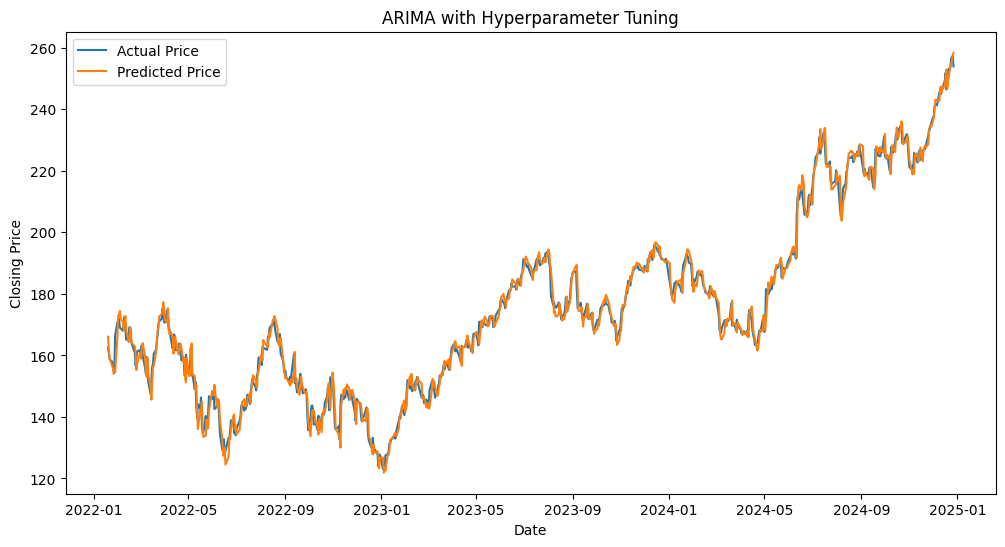

In [20]:
plt.figure(figsize=(12,6))

plt.plot(test.index,results["Actual"],label="Actual Price")

plt.plot(test.index,results["Predicted"],label="Predicted Price")

plt.title("ARIMA with Hyperparameter Tuning")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()